In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from matplotlib import pyplot
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt

In [ ]:
# random seed for always same results
tf.random.set_seed(678)
print(tf.__version__)

2.20.0


### model

In [ ]:
model = Sequential()
# first dense layer
model.add(Dense(units=10, input_shape=(2,), activation='sigmoid'))
model.add(Dense(units=10, activation='sigmoid'))
#model.add(Dense(units=4, activation='sigmoid'))
#model.add(Dense(units=2, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))
# loss function and optimization

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(tf.keras.optimizers.SGD(learning_rate=0.2), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

### Simple Data Xy

In [ ]:
X = np.array([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = np.array([0.,1.,1.,1.])

In [ ]:
# generate 2d classification dataset
X, y = make_moons(n_samples=50, noise=.06)

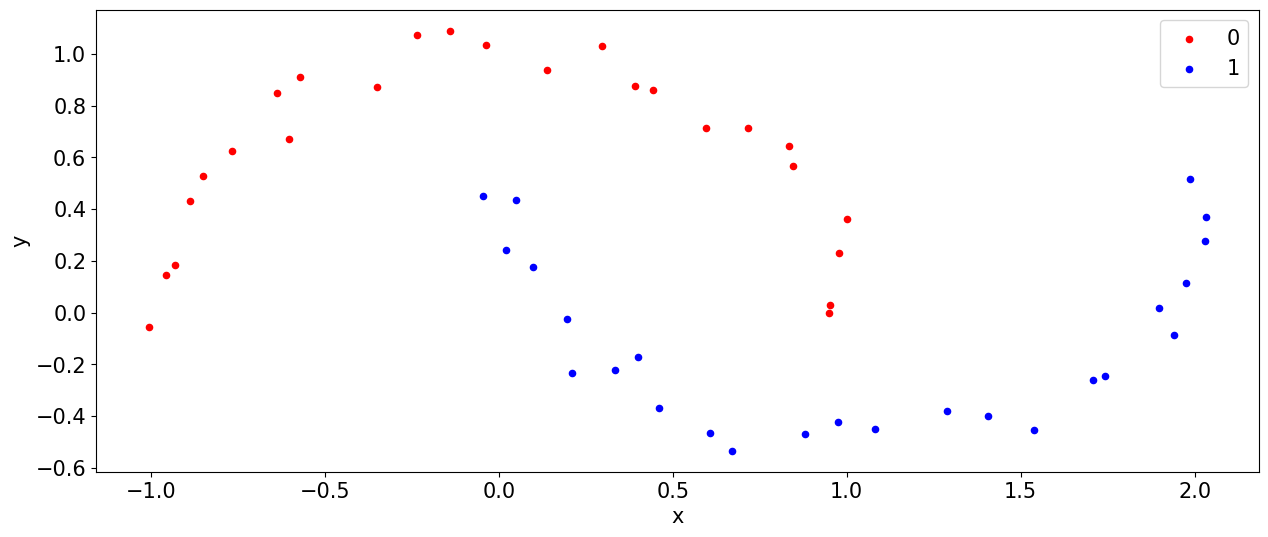

In [ ]:
# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue', 2:'green'}
fig, ax = pyplot.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

### model.fit

In [ ]:
class callback(tf.keras.callbacks.Callback):
    SHOW_NUMBER = 1000
    counter = 0
    epoch = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch = epoch

    def on_train_batch_end(self, batch, logs=None):
        if self.counter == self.SHOW_NUMBER or self.epoch == 1:
            print('Epoch: ' + str(self.epoch) + ' loss: ' + str(logs['loss']))
            if self.epoch > 1:
                self.counter = 0
        self.counter += 1

In [ ]:
batchNum = 100
epochNum = 5000

In [ ]:
history = model.fit(X, y, batch_size=batchNum, epochs=epochNum, callbacks=[callback()], verbose=0)

Epoch: 1 loss: 2.6657891273498535
Epoch: 1000 loss: 0.28565743565559387
Epoch: 2000 loss: 0.26674360036849976
Epoch: 3000 loss: 0.26251858472824097
Epoch: 4000 loss: 0.2605001926422119


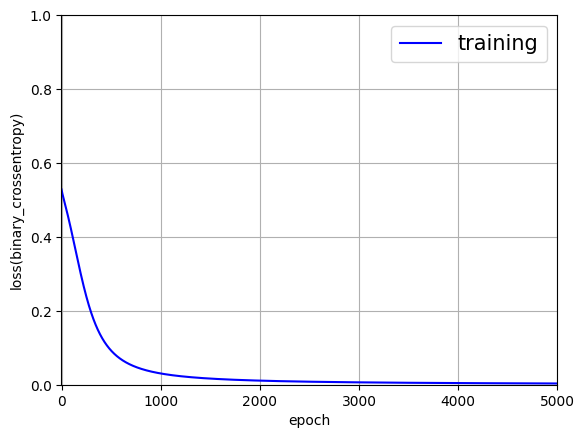

In [ ]:
plt.plot(pd.DataFrame(history.history)[['loss']],'b', label='training')
# plt.figure(figsize=(5,5), dpi=10000, facecolor='w', edgecolor='k')
plt.xlabel("epoch")
plt.ylabel("loss(binary_crossentropy)")  # "Loss(MAE)"  logcosh
plt.rcParams['figure.figsize'] = [15, 6]
font = {'weight' : 'normal', 'size' : 15}
plt.rc('font', **font)
# plt.title('node #:' + str(nodeNum)+' / layer #:'+str(layerNum))
plt.grid(True)
plt.legend()
plt.xlim(-1, epochNum+1)
plt.ylim(0, 1)
# plt.savefig(MODEL_SAVE_FOLDER_PATH+'_learningcurve_'+case_name+'.png', dpi=300)
plt.show()

In [ ]:
print("first layer weights: ",model.layers[0].get_weights()[0])
print("first layer bias: ",model.layers[0].get_weights()[1])
print("second layer weights: ",model.layers[1].get_weights()[0])
print("second layer bias: ",model.layers[1].get_weights()[1])

first layer weights:  [[-2.4943943  5.1158586]
 [-2.4029224  5.1737437]]
first layer bias:  [ 1.1949189 -2.5736067]
second layer weights:  [[-4.361506]
 [ 9.8045  ]]
second layer bias:  [-2.288508]


In [ ]:
py = model.predict(X)
lpy = tf.cast(py > 0.5, dtype=tf.float32)
for i in range(0, len(py), 1):
  print(y[i], py[i], lpy.numpy()[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
0.0 [0.00709128] [0.]
1.0 [0.9970846] [1.]
1.0 [0.9971747] [1.]
1.0 [0.99939317] [1.]


In [ ]:
model.weights

[<KerasVariable shape=(2, 2), dtype=float32, path=sequential/dense/kernel>,
 <KerasVariable shape=(2,), dtype=float32, path=sequential/dense/bias>,
 <KerasVariable shape=(2, 4), dtype=float32, path=sequential/dense_1/kernel>,
 <KerasVariable shape=(4,), dtype=float32, path=sequential/dense_1/bias>,
 <KerasVariable shape=(4, 6), dtype=float32, path=sequential/dense_2/kernel>,
 <KerasVariable shape=(6,), dtype=float32, path=sequential/dense_2/bias>,
 <KerasVariable shape=(6, 4), dtype=float32, path=sequential/dense_3/kernel>,
 <KerasVariable shape=(4,), dtype=float32, path=sequential/dense_3/bias>,
 <KerasVariable shape=(4, 2), dtype=float32, path=sequential/dense_4/kernel>,
 <KerasVariable shape=(2,), dtype=float32, path=sequential/dense_4/bias>,
 <KerasVariable shape=(2, 1), dtype=float32, path=sequential/dense_5/kernel>,
 <KerasVariable shape=(1,), dtype=float32, path=sequential/dense_5/bias>]

In [ ]:
lpy = np.array(lpy)
print(lpy)

[[0.]
 [1.]
 [1.]
 [1.]]


In [ ]:
lpy = np.reshape(lpy,(4,))
print(y.shape, lpy.shape)

(4,) (4,)


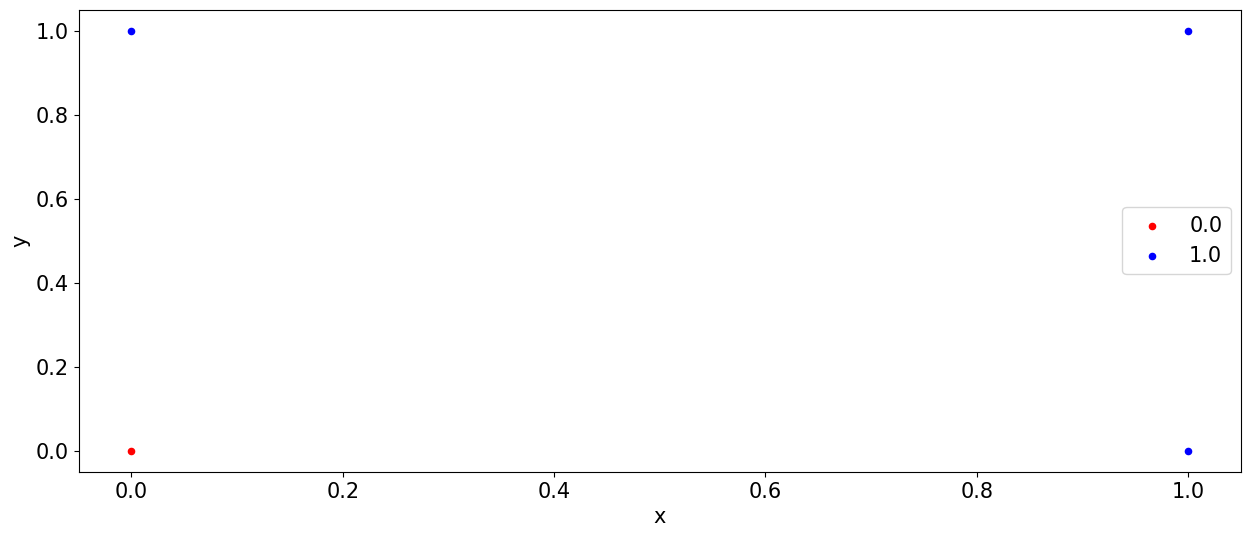

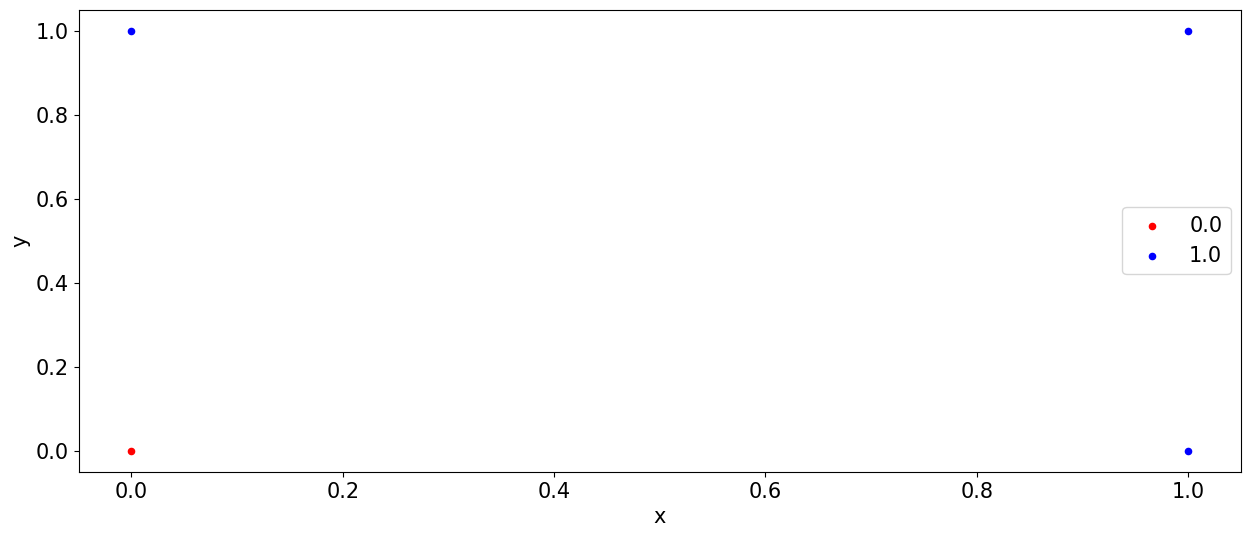

In [ ]:
colors = {0:'red', 1:'blue'}

df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
grouped = df.groupby('label')
fig, ax = pyplot.subplots()
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

df = DataFrame(dict(x=X[:,0], y=X[:,1], label=lpy))
grouped = df.groupby('label')
fig, ax = pyplot.subplots()
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

# generate blobs of points with a Gaussian distribution.

In [ ]:
# generate 2d classification dataset
X, y = make_blobs(n_samples=100, centers=2, n_features=2)

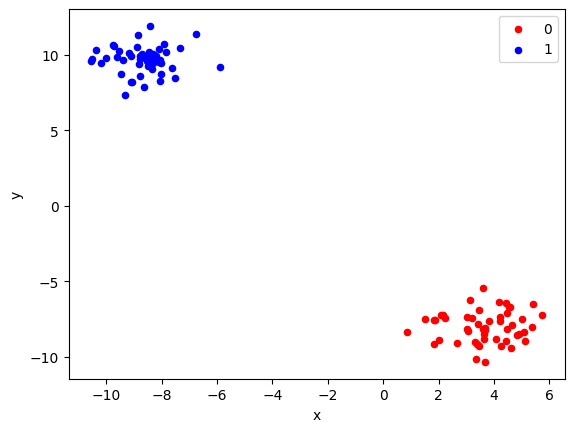

In [ ]:
# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue', 2:'green'}
fig, ax = pyplot.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

In [ ]:
np.set_printoptions(linewidth=220, precision=2)
print(X.T)

[[  2.66  -8.44  -9.48   3.67  -8.1    5.03   1.86  -9.76   4.21   5.37   3.14   3.21   4.24   3.61   3.36  -8.32   4.42  -9.13  -9.54   1.85 -10.5    0.87  -9.09   3.84   3.68   3.05  -8.85  -8.06   1.5   -9.19  -9.33
   -7.63   2.16  -9.61  -7.53  -8.08   3.63   3.41   3.46  -7.91  -7.36   4.55   4.45   4.65  -5.91   5.74 -10.38  -8.33   4.48  -9.1   -8.24   3.64   4.24   2.24  -9.74  -8.46  -8.52  -8.83  -8.66  -8.71  -7.86 -10.01
    5.4    5.13   2.01   4.89   5.08  -8.22  -8.89   4.08   2.08   3.02   4.83  -8.31   3.46  -8.1  -10.55  -8.04  -8.36  -9.38 -10.18   3.66  -6.76   4.48   3.3   -8.8   -8.62  -8.78   4.2    3.03   3.38   4.61  -8.32
   -8.78   1.83  -8.4    4.59  -8.5    3.59  -8.01]
 [ -9.13  11.91   8.7   -8.24  10.4   -7.51  -7.57  10.66  -7.64  -8.03  -6.23  -7.41  -7.4   -5.46 -10.18   9.46  -6.42   9.91  10.25  -9.18   9.74  -8.38   8.19  -7.61 -10.35  -8.28  11.31   9.65  -7.49  10.08   7.32
    9.11  -7.22   9.88   8.48   8.27  -8.82  -7.87  -9.28  10.72  10.46 

In [ ]:
print(y)

[0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 0 0 1 1 0 1 1 1 0 1 1 1 0 0 0 1 1 0 0 0 1 0 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 0 1 0 1 0 1]


In [ ]:
# generate 2d classification dataset
X, y = make_moons(n_samples=100, noise=.16)

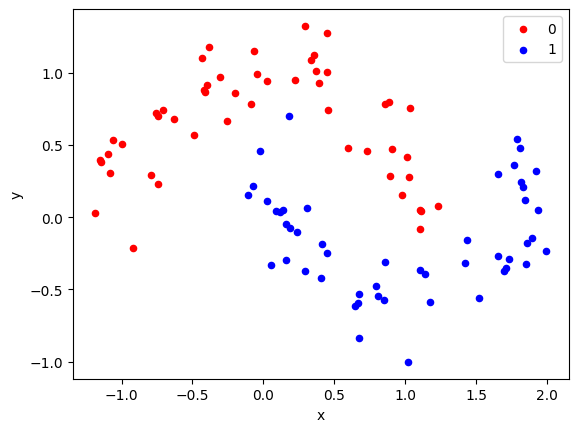

In [ ]:
# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue', 2:'green'}
fig, ax = pyplot.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
pyplot.show()

In [ ]:
np.set_printoptions(linewidth=220, precision=2)
print(X.T)

[[ 6.58e-01  2.94e-01  6.40e-01  1.03e+00  3.46e-01  1.69e+00  1.38e+00  2.42e-01  5.44e-01 -1.28e-02  2.63e-01  1.81e+00 -2.55e-01  4.83e-01  2.07e+00  7.99e-01  1.40e+00  2.19e+00  3.20e-01  1.48e-03 -6.06e-01
   1.34e+00  1.83e+00  1.83e+00 -1.42e-01  9.03e-01  5.05e-01 -3.48e-01  2.18e-01  1.18e+00  8.30e-01  9.53e-01  3.62e-01  1.67e-01  7.88e-01 -5.87e-01  1.67e-01 -9.66e-01  8.64e-01  1.03e+00  7.60e-01  2.53e-01
   4.57e-02  2.06e+00  6.73e-01 -9.96e-01  1.93e+00  8.60e-01 -9.12e-03 -7.18e-01 -8.49e-01  1.38e+00  1.66e+00  7.86e-02  1.36e+00  8.80e-01 -9.71e-01  2.54e-01 -9.33e-01  6.42e-01  7.60e-01  1.35e+00  4.24e-01
   5.62e-01 -1.61e-01  2.76e-01  1.79e+00  2.33e-01 -1.04e+00 -8.05e-01  3.27e-01  8.81e-01  1.18e+00 -1.13e+00  2.12e-01 -1.01e-01  1.11e+00  1.31e+00 -1.00e+00  8.91e-01  6.29e-01  5.26e-02  1.99e+00  6.46e-01
   1.76e+00 -8.29e-01 -8.31e-01  1.97e+00  1.84e+00  8.14e-01 -6.00e-01  1.13e+00 -9.79e-01  6.49e-02  5.23e-01  1.42e-01  1.84e+00  6.16e-01 -9.45e-01 

In [ ]:
print(y)

[0 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 1 1 1 1 0 1 0 1 0 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 1
 0 1 0 1 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 0 0 0 0 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 0 1 1 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0
 1 1 1 1 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 1 1 1 0 1 0 1 0 0 0 0 1 1 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 0]


# ML ex2data1

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##### ex2data1, data2
https://drive.google.com/file/d/176uBDnnuoyLQuqR2oeWC3BkBL023puwQ/view?usp=sharing

https://drive.google.com/file/d/1EJf9oTrbjW-jE6oJyrfA1ukuQU0nyxbw/view?usp=sharing

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DL2022/notebook/data/ex2data1.txt', sep=',', names=['Exam 1 Score', 'Exam 2 Score', 'Result'], header=None)

In [ ]:
data

,Exam 1 Score,Exam 2 Score,Result
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1
...,...,...,...
95,83.489163,48.380286,1
96,42.261701,87.103851,1
97,99.315009,68.775409,1
98,55.340018,64.931938,1


In [ ]:
import seaborn as sns

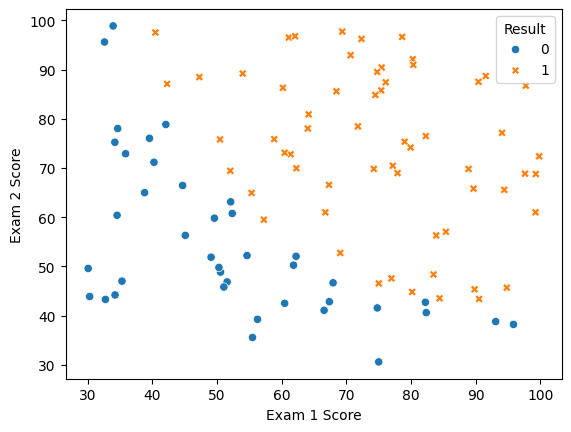

In [ ]:
g =sns.scatterplot(x = 'Exam 1 Score', y = 'Exam 2 Score', hue = 'Result', data = data, style = 'Result')

In [ ]:
# decision boundary
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
pred = model.predict(grid, verbose=0)
zz = pred.reshape(xx.shape)

plt.figure(figsize=(6, 5))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    c='red',
    marker='d'
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    c='lime',
    marker='s'
)

plt.contour(
    xx,
    yy,
    zz,
    levels=[0.5],
    colors='magenta',
    linewidths=2
)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()
